### Lecture 15

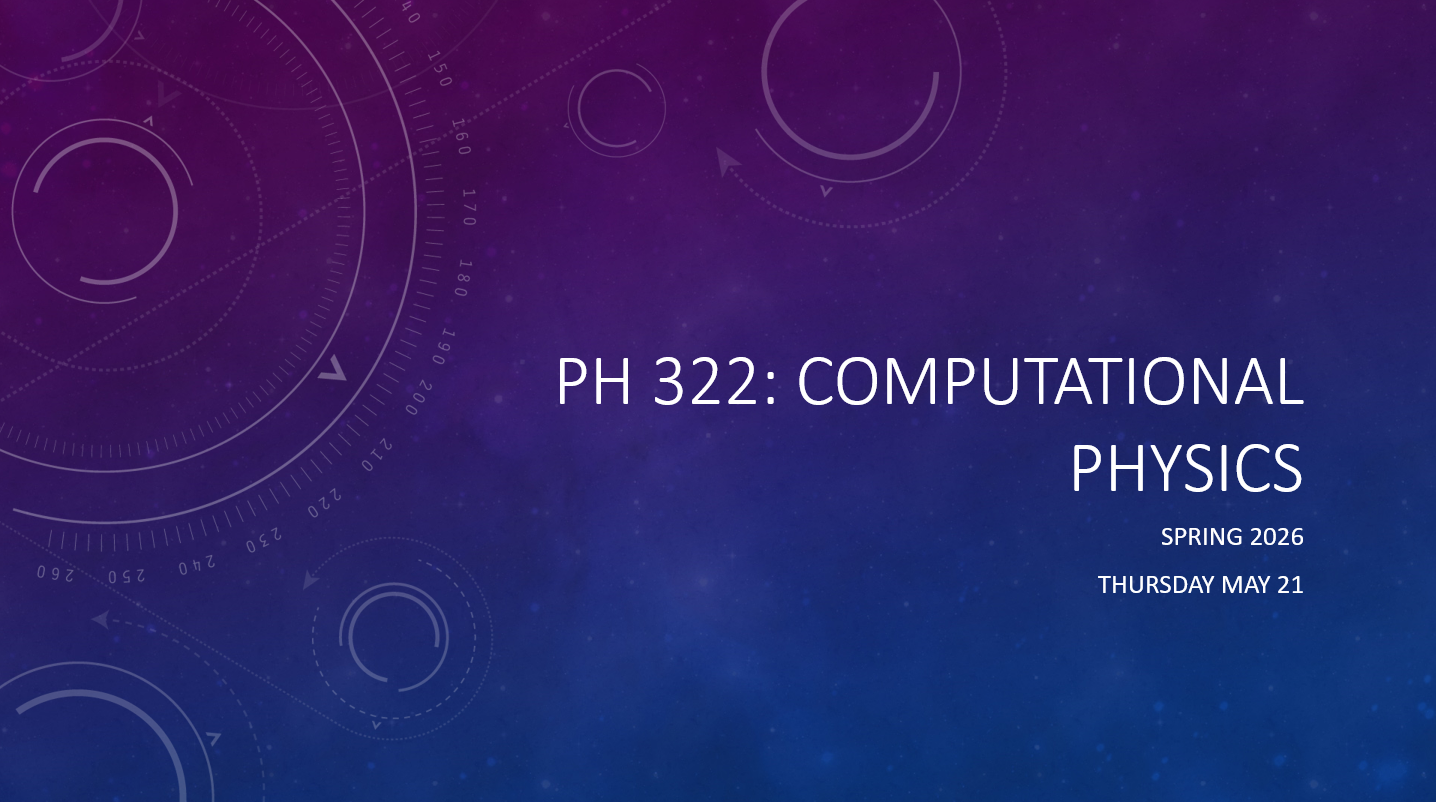

In [ ]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture15.png"))

**Announcements**
* Grace period for HW7 due tonight.
* You should be working on your student project.


**Last Class**
* Partial differential equations
  * Laplace equation
  * Poisson equation
  * Jacobi method
  * Gauss-Seidel method
  * Overrelaxation


**Today's Class**
  * Diffusion equation
  * Forward-Time Centered-Space (FTCS) method
  * Numerical stability




##  Initial-valued partial differential equations

In these last partial differential equations, e.g. Laplace's and Poisson's problems, the function we solved for, $\phi(x,y)$, was a function of two spatial dimensions. In these cases the boundary values were specified along the spatial boundaries of the function, *i.e.*, we specified the potential along the walls of the box.  

But consider this PDE, the heat or diffusion equation given by:

$$
\frac{\partial \phi}{\partial t} = D\frac{\partial ^2 \phi}{\partial x^2}
$$

where $\phi$ represents some quantity that can be diffused, like heat or the concentration of a gas, $D$ is the diffusion coefficient, $t$ is time, and $x$ is a spatial variable. This equation can be used to describe the flow of heat or fluids due to random diffusive processes.

The details of the equation don't matter for now, but note that the solution to the equation $\phi$ is a function of both time and space.  Therefore the solution can be visualized as a set of values bounded by both time and space:

![ch9_initial_value_problem.PNG](attachment:ch9_initial_value_problem.PNG)

In order to solve this problem as we did before with either the Jacobi or Gauss-Seidel method with relaxation we need the value of $\phi$ along the four boundaries. But since one of the boundaries is time, this would require us knowing the function $\phi$ at the end of the time interval. But most often we only know it at the beginning of the time interval, that is the initial condition.

Because of this limitation, the methods we've used before to solve PDEs won't work, since we can't calculate partial derivatives at the interior grid points without knowing the function along all of its boundaries.  

### The Forward-Time Centered-Space (FTCS) method

One method to solve initial-valued PDEs is using the **forward-time centered-space** method. The trick here is to turn the initial-valued PDE problem into a system of ordinary differential equations which we can solve with one of our ODE methods, such as the Euler or Runge-Kutta methods.

To do this we first divide the spatial dimension into a number of grid points as shown below. We specify the function $\phi$ at each grid point as shown.


![ch9_ftcs_method_diagram.PNG](attachment:ch9_ftcs_method_diagram.PNG)

The value of $\phi$ at each grid point can be considered a separate variable. For example, we can think of $\phi(x_0+a,t)$ as variable $\phi_{x_0+a}(t)$ which is only a function of $t$, and $\phi(x_0+2a,t)$ as variable $\phi_{x_0+2a}(t)$.

Doing so, turns the partial differential equation into a number of ordinary differential equations with time $t$ as the independent variable. Therefore if we divide the spatial dimension into $M$ grid points we have $M$ variables, and $M$ equations to solve. We then solve the ODE for each variable $\phi_m(t)$.

### Apply the FTCS method to the diffusion equation

Let's now apply the FTCS method to the diffusion equation:

$$
\frac{\partial \phi}{dt} = D\frac{\partial ^2 \phi}{\partial x^2}.
$$



First, we write the partial second derivatives in the RHS in the equation like we did before using central differences:

$$
\frac{\partial^2\phi}{\partial x^2} = \frac{\phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t)}{a^2}
$$

so the diffusion equation becomes

$$
\frac{d \phi}{dt} =  \frac{D}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right),
$$

where $a$ is the gap spacing between the grid points along the spatial dimenision. It is determined by the physical length of the spatial interval and the number of grid points $M$.

Here $\phi$ means the values of $\phi$ along only one row, not a function of  $x$. So we now have an ordinary differential equation, not partial. This means we can use one of our ODE methods to solve it.

At each grid point in the spatial dimension we have one of these equations. So let's just say we have 3 interior grid points at $x_1, x_2, x_3$, then we have these three equations to solve:

$$
\frac{d \phi_1}{dt} =  \frac{D}{a^2}\left( \phi_2 (t) + \phi_0(t) - 2\phi_1(t) \right)
$$

$$
\frac{d \phi_2}{dt} =  \frac{D}{a^2}\left( \phi_3 (t) + \phi_1(t) - 2\phi_2(t) \right)
$$

$$
\frac{d \phi_3}{dt} =  \frac{D}{a^2}\left( \phi_4 (t) + \phi_2(t) - 2\phi_3(t) \right)
$$

where:

$$
\phi_0(t)= \phi(x_0,t)
$$

$$
\phi_1(t) = \phi(x_0 + a,t)
$$

$$
\phi_2(t) = \phi(x_0+2a,t)
$$

$$
\phi_3(t) = \phi(x_0+3a,t)
$$

$$
\phi_4(t) = \phi(x_0+4a,t).
$$






We can write this system of differential equations in vector form like we have done before:

$$
\frac{d \mathbf{r}}{dt} = \mathbf{f}({\mathbf{r}, t}),
$$

where $\mathbf{r} = (\phi_1, \phi_2, \phi_3)$, and $\mathbf{f}({\mathbf{r}, t}) = (f_1,f_2,f_3)$, where



$$
f_1 = \frac{D}{a^2}\left( \phi_2 (t) + \phi_0(t) - 2\phi_1(t) \right)
$$

$$
f_2 = \frac{D}{a^2}\left( \phi_3 (t) + \phi_1(t) - 2\phi_2(t) \right)
$$

$$
f_3 =  \frac{D}{a^2}\left( \phi_4 (t) + \phi_2(t) - 2\phi_3(t) \right)
$$


We have already solved a system of ODEs before. What method should we use here?

Although normally we would want to use the 4th-order RK for most ODEs, here we can get away with using Euler's method, because the approximation error we incurred when replacing the partial derivatives with central differences is much larger than the approximation error on the RK4 method, so we might as well use the *slightly-easier-to-code* Euler's method (though if you have RK code lying around, it's really not that difficult to use, even though we don't expect to get any gain in accuracy)

Using Euler's method, we cast each ordinary differential equation into this form:

$$
\frac{d\phi}{dt} = f(\phi,t)
$$

and the solution at time $t+h$ is given by:

$$
\phi(t+h) = \phi(t)+h\frac{d\phi(t)}{dt}
$$

$$
= \phi(t)+hf(\phi,t)
$$

and in this case:

$$
f(\phi,t) = \frac{D}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$

so

$$
\phi(x,t+h) = \phi(x,t) + h\frac{D}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$



So if we know the initial value of $\phi(t)$ at all grid points $x_i$, we then can step forward and calculate $\phi(x,t)$ over the entire time interval.

### Practice Exercise - Solve the diffusion equation using the FTCS method

Let's practice coding the FTCS for the following diffusion problem.

The flat base of a container made of a 1 cm thick stainless steel is initially at a uniform temperature of $20^\circ$C everywhere. The container is placed in a bath of cold water at $0^\circ$C and filled with hot water at $50^\circ$C.

Calculate the temperature profile of the steel as a function of distance $x$ from the hot side to the cold side, and as a function of time. For simplicity treat the base of the container as being arbitrarily wide, so that its temperature profile is the same everywhere, and assume that neither the hot nor the cold water changes temperature.

![image.png](attachment:66aea9d7-96c2-41d5-8b28-576350517744.png)

Thermal conduction is governed by the heat equation:

$$
\frac{\partial \phi}{dt} = D\frac{\partial ^2 \phi}{\partial x^2}
$$

where $D$ is the diffusion coefficient for steel, $4.25\times 10^{-6}$ m$^2$s$^{-1}$.

We have already derived the system of equations we need to solve above:

$$
\frac{d \phi}{dt} =  \frac{hD}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$


We can divide the $x$-dimension up into $M=100$ grid points, so we have a system of 98 equations to solve, since we solve only on the interior grid points.

The initial condition specifies the temperature profile across the steel at time $0$:

$$
\phi(0,t=0) = 50^\circ C \qquad \text{top}
$$

$$
\phi(M-1,t=0) = 0^\circ C \qquad \text{bottom}
$$

$$
\phi(1:M-2,t=0) = 20^\circ C \qquad \text{everywhere else}
$$

The spatial boundary condition requires the temperatures at the top and bottom surfaces to be maintained constant over the time interval:


$$
\phi(0,t) = 50^\circ C \qquad \text{top}
$$

$$
\phi(M-1,t) = 0^\circ C \qquad \text{bottom}
$$

or using Python array slicing notation:



$$
\phi(0,:) = 50^\circ C   
$$

$$
\phi(M-1,:) = 0^\circ C   
$$


![image.png](attachment:4dbc2b25-dffa-4d50-8bcd-2e3850c565fa.png)

We solve the equations using Euler's method:

$$
\phi(x,t+h) = \phi(x,t) + \frac{hD}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$



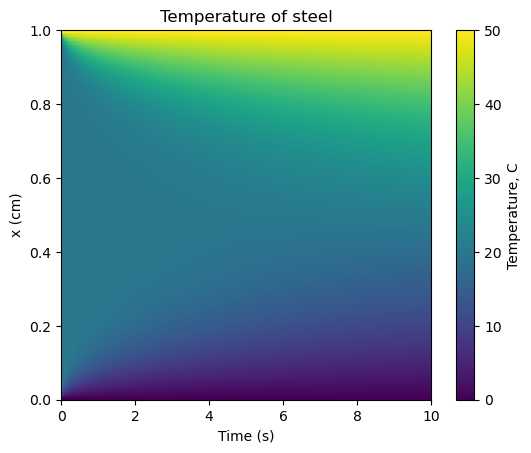

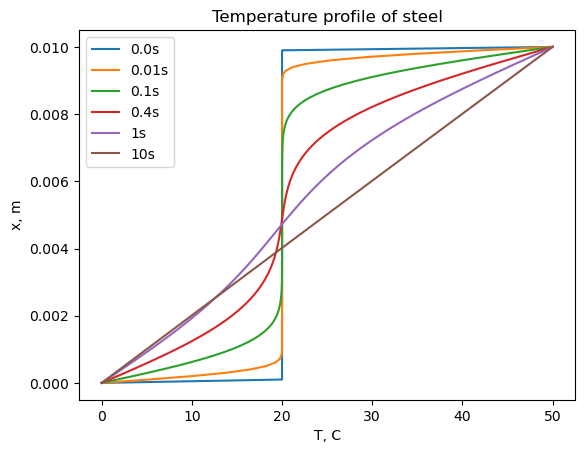

In [ ]:
# Example 9.3 Heat Equation
# Practice solving initial value PDE using FTCS method





The top plot shows the temperature across the steel as a function of both the thickness of the steel, $x$,  and time. The bottom plot shows the temperature profile across the steel at different times. Notice that at t=0, the steel is at its initial temperature of $20^{\circ} C$ everywhere except at the end points. Then as time progresses the heat signatures penetrate into the steel, until at $t=10$ s, there is a constant temperature gradient across the steel.

### Application of FTCS to the wave equation

We see above the FTCS method works well in solving the diffusion equation. We can calculate the solution out to time $t$ and the solution remains stable.

Let's try applying the FTCS method to the wave equation. Here again is the wave equation in one dimension:

$$
\frac{\partial^2\phi}{\partial t^2} = v^2\frac{\partial^2\phi}{\partial x^2}
$$

where $v$ is the wave velocity.

In order to solve this using the FTCS method, we again divide the spatial dimension, in this case $x$,  into a number of grid points separated by width $a$, and treat the value of the solution $\phi$ along $x$ as separate variables. Doing so, turns the partial derivative into an ordinary derivative.

We write the partial derivative as before using finite differences:

$$
\frac{d^2\phi_x}{d t^2} = \frac{v^2}{a^2}\left[\phi_{x+a}(t)+\phi_{x-a}(t)-2\phi_x(t)\right]
$$


Since this is a second-order differential equation we break it into two first-order equations by defining a new variable $\psi$:

$$
\frac{d\phi_x}{dt} = \psi_x(t)
$$

With this definition we can write the second derivative as:

$$
\frac{d \psi_x}{dt} = \frac{v^2}{a^2}\left[\phi_{x+a}(t)+\phi_{x-a}(t)-2\phi_x(t)\right]
$$

And to solve this using Euler's method, the solutions at each time step are given by:   

$$
\phi_x(t+h) = \phi_x(t) +h\psi_x(t)
$$

$$
\psi_x(t+h) = \psi_x(t) + h\frac{v^2}{a^2}\left[\phi_{x+a}(t) + \phi_{x-a}( t)-2\phi_x(t)\right]
$$

We can calculate the solutions given some boundary conditions of the problem.

### Practice Exercise - Application of FTCS method to the wave equation.

Let's assume this wave equation describes the displacement of a string of length $L=1.0m $, and the velocity of a wave on the string is 100 m/s.  The string is initially stretched to be in the shape of a sine wave, $\sin{2\pi x/L}$, and held at rest. Therefore  $\frac{d \psi}{dt}=0$ initially.

If you have your FTCS code working for the diffusion equation above, copy it below and revise it for the wave equation. Use $M=100$ grid points in the $x$-dimension, and $N=10000$ grid points in the time dimension. Calculate the solution from $t=0$ milliseconds to $t=20$ milliseconds. Make a plot of the displacments of the wave at a couple of different times in the interval.

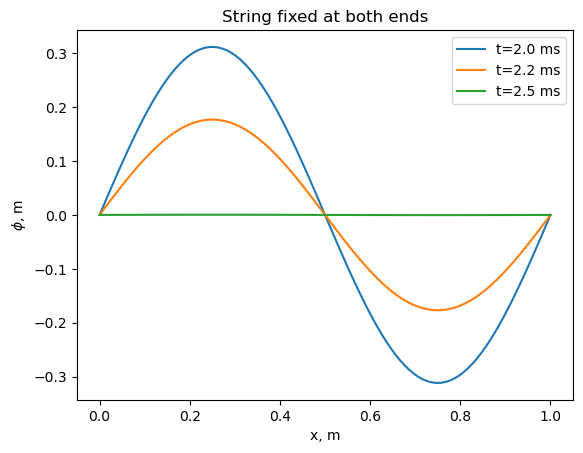

In [ ]:
# Use the FTCS method to solve the wave equation.


Early in the time interval we see the solution is well-behaved, and the wave oscillates about the midpoint.  Let's plot the wave later in the interval:

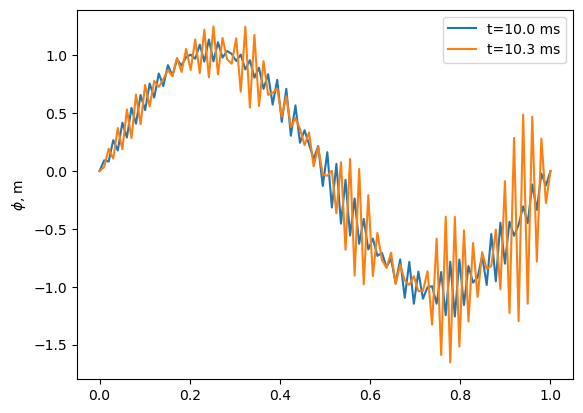

In [ ]:
time = t2/2 # specify time to sample function, s
i = np.argmin(abs(tvalues - time))
# plot phi as a function of xt
plt.plot(xvalues, phi[:,i],label = f"t={time*1000:0.1f} ms")

time = t2/1.95 # specify time to sample function, s
i = np.argmin(abs(tvalues - time))
# plot phi as a function of xt
plt.plot(xvalues, phi[:,i],label = f"t={time*1000:0.1f} ms")
plt.ylabel(r"$\phi$, m")
plt.legend()
plt.show()


However, now we see the solution is becoming numerically unstable. If we plot the solution even later:

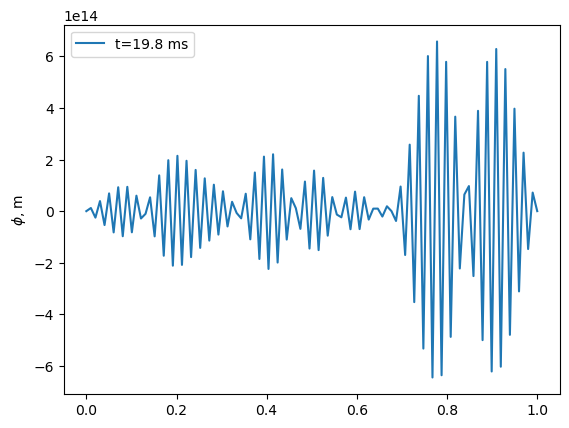

In [ ]:
time = t2/1.01 # specify time to sample function, s
i = np.argmin(abs(tvalues - time))
# plot phi as a function of xt
plt.plot(xvalues, phi[:,i],label = f"t={time*1000:0.1f} ms")
plt.ylabel(r"$\phi$, m")
plt.legend()
plt.show()

It just continues to get worst. Notice the amplitude is $1e14$. If we continue much longer the solution gets so big it overflows.

Here we can watch the destruction of the wave play out using a VPython animation.

In [2]:
!pip install vpython

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.1 MB/s eta 0:00:00
  Created wheel for 

In [1]:
# vpython animation of vibrating string.

from vpython import canvas, vector, color, curve, rate, wtext
M = 10
canvas(width=500, height=300, center=vector(.5,0,0))

wave = curve(retain=M, color=color.red)

tstart = 1e-3
tend = 60e-3
tstep = 1e-5

timestamp = wtext(text=f"t={tvalues[0]:0.4f}s")

for i in range(N):
    timestamp.text=f"t={tvalues[i]*1000:0.1f} ms"
    displacement = phi[:,i]
    rate(50)
    for i in range(M):
        d = vector(xvalues[i],0.5*displacement[i],0)
        wave.append(d)

SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


What we see here is that the use of the FTCS method to solve the wave equation is numerically unstable, except for very short time periods, and this is a general result when the FTCS method is used to solve the wave equation.

### von Neumann analysis of numerical stability

To find out why the FTCS method works for some equations but not others, we return to the FTCS equation for the diffusion equation:

$$
\phi(x,t+h) = \phi(x,t) + h\frac{D}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$

Mathematician and physicist John von Neumann recognized that we can write the solution $\phi(x,t)$ at any time $t$ as a Fourier series of the form;

$$
\phi(x,t) = \sum_k c_k(t)e^{ikx},
$$

where we make use of the complex exponential to represent sine and cosine terms.

Essentially what we are doing is writing the values along a slice through the solution space $(x,t)$ at some time $t$ as a Fourier series. Just to better visualize, here again is the solution $\phi(x,t)$;


![image.png](attachment:3d4f5c50-be4c-4538-a69e-fb882b853169.png)

And here are some slices through the solution space at some values of time $t$:

![image.png](attachment:cea0d6a2-8332-4219-aa45-50ff80835a77.png)

The reason we might want to do this is to track what happens to the Fourier terms as we march our solution forward in time. In the case of the wave equation, the solution diverged, which indicates one or more terms in the Fourier series diverged. That didn't happen with the diffusion equation. Since the magnitude of each term in the Fourier series is determined by each term's coefficient, another way of diagnosing the problem, is to see how the Fourier coefficients change from time step to time step.

To investigate we'll see what controls the evolution of the coefficient for a single term of the Fourier series. Presumably the rules that govern one coefficient, govern all.

So we take one term from the Fourier series of $\phi(x,t)$:

$$
\phi(x,t) \sim c_k(t)e^{ikx}
$$

and substitute it into the FTCS equation we derived for the heat diffusion equation above:

$$
\phi(x,t+h) = c_k(t)e^{ikx} + h\frac{D}{a^2}\left( c_k(t)e^{ik(x+a)} + c_k(t)e^{ik(x-a)} - 2c_k(t)e^{ikx} \right).
$$

$$
= c_k(t)e^{ikx}[\,1+ h\frac{D}{a^2}\left(e^{ika} + e^{-ika} - 2 \right) ]\,
$$

With the use of the trig identities

$$
e^{ika} + e^{-ika} = 2\cos(ka)
$$

$$
1-\cos(ka) = 2\sin^2\frac{1}{2}(ka),
$$


we find that:

$$
\phi(x,t+h) = \underbrace{\left[1-h\frac{4D}{a^2}\sin^2{\frac{1}{2}ka}\right]c_k(t)}_{c_k(t+h)}e^{ikx}
$$

We are interested in everything that scales $e^{ikx}$, because that determines the magnitude of the term. Everything in the underbracket is $c_k(t+h)$, which is the Fourier coefficient at the next time step $t+h$:

$$
c_k(t+h) = \underbrace{\left[1-h\frac{4D}{a^2}\sin^2{\frac{1}{2}ka}\right]}_{\text{prefactor}}c_k(t)
$$


We see it is equal to the coefficient at the previous time step $c_k(t)$ multiplied by a prefactor.

If the absolute value of the prefactor is greater than 1, then with each successive time step, the Fourier coefficient will get larger and larger and will diverge. If on the other hand the prefactor is less than 1, the solution will remain bounded.

Since $\sin^2{\frac{1}{2}ka}$ will always be positive, as will $h, D,$ and $a$, the second term in the prefactor will always be positive, hence the prefactor will never be greater than +1.

In order for the prefactor not to be less than $-1$, the second term can't be greater than $2$, so this sets a condition for numerical stability:

$$
h\frac{4D}{a^2}\sin^2{\frac{1}{2}ka} \le 2
$$

Since $\sin^2{\frac{1}{2}ka}$ will at most be 1, the inequality becomes:

$$
h\frac{4D}{a^2} \le 2
$$

or:

$$
\boxed{h \le \frac{a^2}{2D}}
$$

So this is the result we are interested in. What it tells us is that the solution to the diffusion equation using the FTCS method will remain stable, if this condition is met.

As a reminder, $h$ is the size of the time step, $a$ is the spacing between the grid points in the spatial dimension, and $D$ is the diffusion coefficient.


![image.png](attachment:87f31068-eb1f-4f29-bf5a-c24fc14ab0e9.png)


Let's see if this condition is indeed met for the heat equation problem we solved above:



$$
a=\frac{L}{M-1}
$$

With $L=0.01$ m and $M=100$, $a=0.0001$ m.

$$
h = \frac{t_2-t_1}{N}
$$

With $t_2-t_1=10$s and $N=10000$,

$$
h=0.001 s.
$$




And with $D = 4.25\times 10^{-6}m^2s^{-1}$,

$$
\frac{a^2}{2D} = 0.0012 s,
$$

so $h<\frac{a^2}{2D}$, but just barely.

Let's try to induce numerical instability by breaking this condition.

If we keep the diffusion coefficient the same, we can violate the condition by either decreasing $a$, which means increasing the number of grid points in the spatial dimension, or increasing $h$, which means reducing the number of time steps, or both.

Let's decrease the number of time steps by a factor of 10 so $N=1000$ making $h=0.01s$, so now

$$
h>\frac{a^2}{2D},
$$

which should produce instability. Let's see what happens. I just copy my heat equation code from above and change $N$:

C:\Users\cbuten\AppData\Local\Temp\ipykernel_26192\309381843.py:44: RuntimeWarning: overflow encountered in scalar multiply
  r[m,i+1] = r[m,i] + c*(r[m+1,i] + r[m-1,i] - 2*r[m,i])
C:\Users\cbuten\AppData\Local\Temp\ipykernel_26192\309381843.py:44: RuntimeWarning: overflow encountered in scalar subtract
  r[m,i+1] = r[m,i] + c*(r[m+1,i] + r[m-1,i] - 2*r[m,i])
C:\Users\cbuten\AppData\Local\Temp\ipykernel_26192\309381843.py:44: RuntimeWarning: invalid value encountered in scalar add
  r[m,i+1] = r[m,i] + c*(r[m+1,i] + r[m-1,i] - 2*r[m,i])
C:\Users\cbuten\AppData\Local\Temp\ipykernel_26192\309381843.py:44: RuntimeWarning: overflow encountered in scalar add
  r[m,i+1] = r[m,i] + c*(r[m+1,i] + r[m-1,i] - 2*r[m,i])


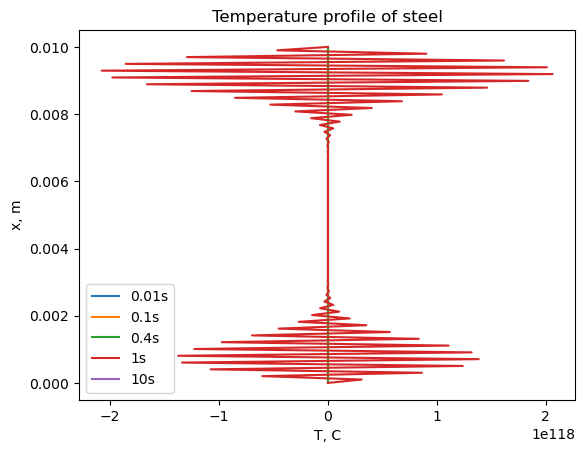

In [ ]:
# Example 9.3 Heat Equation




Sure enough, we get an overflow error which breaks the code. So using the von Neumann analysis we can figure out under which conditions the diffusion equation will be numerically stable using the FTCS method.

### Stability of the wave equation

How about the wave equation? We saw above that the solution to the wave equation was not stable. Under what conditions will it be stable?

The von Neumann analysis for the wave equation is more complicated since now we have two equations (since the wave equation is second-order in time). But we can still derive how the Fourier coefficients of the solutions of both equations evolve from time step to time step like we did above for the heat equation.

Following the same procedure as above, the coefficients at time $t+h$ are related to the coefficients at time $t$ by:

$$
c_{\phi}(t+h) = c_{\phi}(t)  + hc_{\psi}(t),
$$

$$
c_{\psi}(t+h) = c_{\psi}(t)  - hc_{\phi}(t)\frac{4v^2}{a^2}\sin^2{\frac{1}{2}ka}.
$$

Here we have two sets of coefficients for two equations. We can write these two equations in matrix-vector form as:

$$
\mathbf{c}(t+h) = \mathbf{A}\mathbf{c}(t)
$$

where

$$
\mathbf{A} =
\begin{bmatrix}
1 & h \\
-\frac{h4v^2}{a^2}\sin^2{\frac{1}{2}ka} & 1 \\
\end{bmatrix}
$$

So here we see that on every time step the coefficients get multiplied by matrix $\mathbf{A}$.

We can write the vector $\mathbf{c}(t)$ in terms of the eigenvectors of $\mathbf{A}$, $\mathbf{v_1}$ and $\mathbf{v_2}$, as:

$$
\mathbf{c}(t) = \alpha_1\mathbf{v_1} + \alpha_2\mathbf{v_2}
$$

where $\alpha_1$ and $\alpha_2$ are constants.

If we substitute this expression for $\mathbf{c}(t)$ above, we get

$$
\mathbf{c}(t+h) = \mathbf{A}(\alpha_1\mathbf{v_1} + \alpha_2\mathbf{v_2})
$$

$$
= \mathbf{A}\alpha_1\mathbf{v_1} +\mathbf{A}\alpha_2\mathbf{v_2}.
$$

We can rewrite this in terms of the eigenvalues of $\mathbf{A}$, $\lambda_1$ and $\lambda_2$ using the eigenvector equation

$$
\mathbf{A}\mathbf{v} = \mathbf{\lambda}\mathbf{v}:
$$

$$
\mathbf{c}(t+h) = \alpha_1\lambda_1\mathbf{v_1} + \alpha_2\lambda_2\mathbf{v_2}
$$

With this expression, we can write the coefficients at the next time step as:


$$
\mathbf{c}(t+2h) = \mathbf{A}\mathbf{c}(t+h) = \mathbf{A}(\alpha_1\lambda_1\mathbf{v_1} + \alpha_2\lambda_2\mathbf{v_2})
$$

$$
= \alpha_1\lambda_1^2\mathbf{v_1} + \alpha_2\lambda_2^2\mathbf{v_2}.
$$

Repeating this up to time step $mh$, the coefficents are:

$$
\mathbf{c}(t+mh)= \alpha_1\lambda_1^m\mathbf{v_1} + \alpha_2\lambda_2^m\mathbf{v_2}.
$$


The coefficients will diverge if either of the eigenvalues is greater than one, or alternatively, the coefficients will converge only if the magnitudes of the eigenvalues are less than or equal to 1.

By solving the characteristic determinant equation $ det(\mathbf{A}-\lambda\mathbf{I}) = 0$, we find the eigenvalues of $\mathbf{A}$ are:

$$
|\lambda | = \sqrt{1 + \frac{h^24v^2}{a^2}\sin^2{\frac{1}{2}ka}}
$$

But since $\sin^2{\frac{1}{2}ka}$ is always positive, as is $v^2$ and $a^2$, the expression under the radical sign will always be greater than 1, meaning the eigenvalues will always be greater than 1. Therefore the solution will always eventually diverge after enough time steps have elapsed.

So we can't use the FTCS method to solve the wave equation, except for short time intervals.  We find that the FTCS works well for some equations but not for all, which is a general rule of thumb for a lot of numerical methods.

There are other methods to solve the wave equation without producing numerical instabilities (see the discussion of the implicit and Crank-Nicolson methods in the text).

Next week we will take a look at a completely different way to solve PDEs, the spectral or Fourier transform method, which will work with the wave equation.